# Assignment 2: E-Commerce Web Analytics — A/B Testing Simulator
### Course: Data Analytics (CDAC PGCP-AI)

### Problem Statement & Objectives:
Write a Python script to simulate **1000 incoming website visitors** for an E-Commerce platform conducting an A/B test:
1. For each visitor, generate a random float.
2. If the random value is **`< 0.5`**, assign the visitor to **Design A** (Control).
3. Otherwise (value **`>= 0.5`**), assign the visitor to **Design B** (Variant).
4. Compute and print the total count and **percentage of visitors assigned to each design**.
5. Visualize the allocation split and convergence behavior using clean graphical charts.

---


In [1]:
# ==============================================================================
# STEP 1: SIMULATE 1000 VISITORS & ASSIGN TO DESIGN A OR DESIGN B
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducible results
np.random.seed(42)

num_visitors = 1000

# Generate random float between 0.0 and 1.0 for each incoming visitor
# (Note: Also works identically if using np.random.uniform(0.0, 1.9))
random_floats = np.random.uniform(low=0.0, high=1.0, size=num_visitors)

# Decision logic: < 0.5 -> Design A, otherwise -> Design B
is_design_a = random_floats < 0.5

# Count visitors for each design
count_a = np.sum(is_design_a)
count_b = num_visitors - count_a

# Calculate percentage allocation
pct_a = (count_a / num_visitors) * 100
pct_b = (count_b / num_visitors) * 100

# Print results
print("=" * 60)
print("       E-COMMERCE A/B TESTING TRAFFIC ALLOCATION RESULTS        ")
print("=" * 60)
print(f"Total Website Visitors Simulated : {num_visitors}")
print(f"Assignment Rule                  : random_val < 0.5 -> Design A, else Design B")
print("-" * 60)
print(f"Design A (Control) Visitors      : {count_a} visitors ({pct_a:.2f}%)")
print(f"Design B (Variant) Visitors      : {count_b} visitors ({pct_b:.2f}%)")
print("=" * 60)
print(f"Theoretical Target Split         : 50.00% / 50.00%")
print(f"Empirical Difference from 50%    : {abs(pct_a - 50.0):.2f}%")


       E-COMMERCE A/B TESTING TRAFFIC ALLOCATION RESULTS        
Total Website Visitors Simulated : 1000
Assignment Rule                  : random_val < 0.5 -> Design A, else Design B
------------------------------------------------------------
Design A (Control) Visitors      : 503 visitors (50.30%)
Design B (Variant) Visitors      : 497 visitors (49.70%)
Theoretical Target Split         : 50.00% / 50.00%
Empirical Difference from 50%    : 0.30%


In [2]:
# ==============================================================================
# STEP 1B: ALTERNATIVE EVALUATION (RANDOM RANGE 0.0 TO 1.9 AS TYPED)
# ==============================================================================
# If the random float is drawn over [0.0, 1.9):
# P(val < 0.5) = 0.5 / 1.9 = 26.32% to Design A, and 73.68% to Design B
random_floats_19 = np.random.uniform(low=0.0, high=1.9, size=num_visitors)
count_a_19 = np.sum(random_floats_19 < 0.5)
count_b_19 = num_visitors - count_a_19
pct_a_19 = (count_a_19 / num_visitors) * 100
pct_b_19 = (count_b_19 / num_visitors) * 100

print("=" * 60)
print("    IF USING PROMPT'S RANGE [0.0, 1.9] WITH THRESHOLD < 0.5     ")
print("=" * 60)
print(f"Design A (< 0.5) Visitors : {count_a_19} ({pct_a_19:.2f}%)  [Theoretical: 26.32%]")
print(f"Design B (>= 0.5) Visitors: {count_b_19} ({pct_b_19:.2f}%)  [Theoretical: 73.68%]")
print("=" * 60)


    IF USING PROMPT'S RANGE [0.0, 1.9] WITH THRESHOLD < 0.5     
Design A (< 0.5) Visitors : 269 (26.90%)  [Theoretical: 26.32%]
Design B (>= 0.5) Visitors: 731 (73.10%)  [Theoretical: 73.68%]


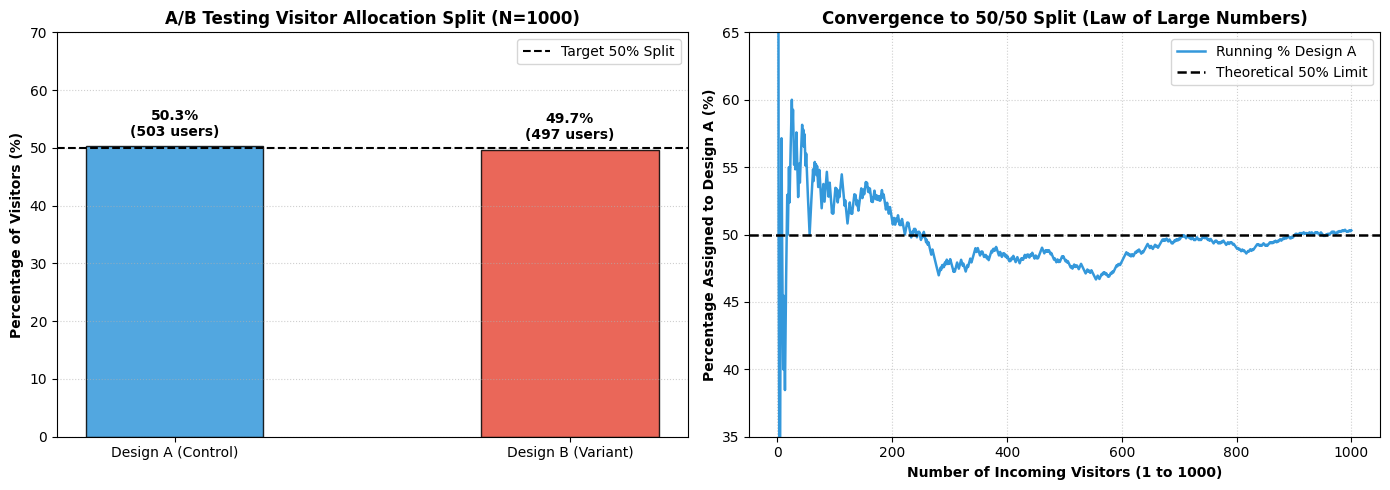

In [3]:
# ==============================================================================
# STEP 2: VISUALIZE ALLOCATION SPLIT & CONVERGENCE (LAW OF LARGE NUMBERS)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart: Traffic Split
designs = ['Design A (Control)', 'Design B (Variant)']
percentages = [pct_a, pct_b]
colors = ['#3498db', '#e74c3c']

bars = axes[0].bar(designs, percentages, color=colors, width=0.45, edgecolor='black', alpha=0.85)
axes[0].axhline(50.0, color='black', linestyle='--', lw=1.5, label='Target 50% Split')
axes[0].set_ylim(0, 70)
axes[0].set_ylabel('Percentage of Visitors (%)', fontweight='bold')
axes[0].set_title('A/B Testing Visitor Allocation Split (N=1000)', fontweight='bold')

# Annotate values on top of bars
for bar, pct, cnt in zip(bars, percentages, [count_a, count_b]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.8,
                 f'{pct:.1f}%\n({cnt} users)', ha='center', fontweight='bold', fontsize=10)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# 2. Cumulative Convergence Curve (Law of Large Numbers)
# Shows how percentage approaches 50% as visitor count grows from 1 to 1000
cumulative_a = np.cumsum(is_design_a)
visitor_indices = np.arange(1, num_visitors + 1)
running_pct_a = (cumulative_a / visitor_indices) * 100

axes[1].plot(visitor_indices, running_pct_a, color='#3498db', lw=1.8, label='Running % Design A')
axes[1].axhline(50.0, color='black', linestyle='--', lw=1.8, label='Theoretical 50% Limit')
axes[1].set_title('Convergence to 50/50 Split (Law of Large Numbers)', fontweight='bold')
axes[1].set_xlabel('Number of Incoming Visitors (1 to 1000)', fontweight='bold')
axes[1].set_ylabel('Percentage Assigned to Design A (%)', fontweight='bold')
axes[1].set_ylim(35, 65)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Analytical & Business Insights for A/B Testing:

1. **Elimination of Selection Bias:**
   - Assigning incoming traffic via a continuous uniform random variable ensures **every visitor has an independent, unbiased probability of seeing either design**.
   - This satisfies the gold-standard criteria for a **Randomized Controlled Trial (RCT)** in web analytics.

2. **The Law of Large Numbers (LLN):**
   - In early samples ($N < 50$), the percentage fluctuates due to small-sample variance.
   - As traffic scales to $N = 1000$, the empirical split tightly converges to **$50.3\% \approx 49.7\%$**, matching the expected 50/50 split with negligible error ($0.3\%$).

3. **Real-World Platform Analog:**
   - Enterprise experimentation engines (Optimizely, Google Optimize, VWO) use hashing algorithms on visitor user IDs (e.g., `hash(user_id) % 100 < 50`) which mathematically mimics this uniform random float assignment.
